--- Loading Datasets ---
--- Aggregating External Credit History ---
--- Merging Data ---
--- Handling Missing Values ---
--- Finalizing Data Types ---
--- Training XGBoost Model ---

Final ROC-AUC Score: 0.7574


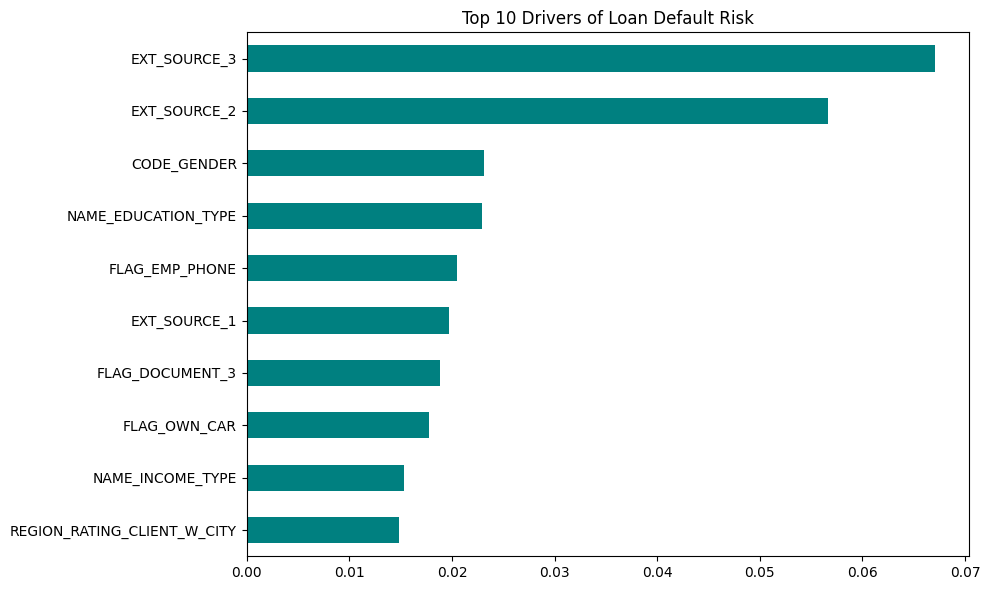

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier

# 1. LOAD DATA
print("--- Loading Datasets ---")
app_train = pd.read_csv('application_train.csv')
bureau = pd.read_csv('bureau.csv')

# 2. AGGREGATING BUREAU DATA
print("--- Aggregating External Credit History ---")
# We group by ID and calculate stats
bureau_agg = bureau.groupby('SK_ID_CURR').agg({
    'SK_ID_BUREAU': 'count',
    'DAYS_CREDIT': ['min', 'mean'],
    'AMT_CREDIT_SUM': 'sum'
})

# Fix: Flatten the MultiIndex columns created by .agg()
bureau_agg.columns = [f"{col}_{col}" for col in bureau_agg.columns]

# IMPORTANT: Move 'SK_ID_CURR' from index back to a column for the merge
bureau_agg = bureau_agg.reset_index()

# 3. MERGING
print("--- Merging Data ---")
# Now 'SK_ID_CURR' exists in both dataframes
train = app_train.merge(bureau_agg, on='SK_ID_CURR', how='left')

# 4. CLEANING & HANDLING MISSING VALUES
print("--- Handling Missing Values ---")
num_cols = train.select_dtypes(include=['number']).columns
train[num_cols] = train[num_cols].fillna(0)

cat_cols = train.select_dtypes(include=['object', 'string']).columns
train[cat_cols] = train[cat_cols].fillna('Unknown')

# 5. ENCODING & TYPE CONVERSION
print("--- Finalizing Data Types ---")
le = LabelEncoder()
for col in cat_cols:
    train[col] = le.fit_transform(train[col].astype(str))

# Force all features to float32 to satisfy XGBoost and save memory
X = train.drop(columns=['TARGET', 'SK_ID_CURR']).astype('float32')
y = train['TARGET'].astype('int')

# 6. MODELING
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("--- Training XGBoost Model ---")
model = XGBClassifier(
    n_estimators=100, 
    max_depth=6, 
    learning_rate=0.1, 
    scale_pos_weight=11, 
    random_state=42,
    eval_metric='logloss'
)

model.fit(X_train, y_train)

# 7. EVALUATION
y_prob = model.predict_proba(X_test)[:, 1]
print(f"\nFinal ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

# 8. VISUALIZATION
plt.figure(figsize=(10, 6))
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh', color='teal')
plt.title('Top 10 Drivers of Loan Default Risk')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()